# DSN Bootcamp Qualification Hackathon 2026 (ML Track)
## Predicting product sales for DSN Mart

**Business problem.** DSN Mart runs stores across Nigeria, from corner shops to flagship hypermarkets. It wants to know what drives sales for each product in each store, so it can plan stock, pricing and store investment.

**Task.** For every row in `test.csv`, predict `total_sales`. This is a regression problem scored by **RMSE** (lower is better).

**How this notebook follows the brief:**
Understand → Analyse → Model → Predict → Communicate

| Section | What the brief asks for |
|---|---|
| 1 | Explore and understand the dataset |
| 2 | Clean and preprocess the data |
| 3 | EDA and analysis of factors that influence sales |
| 4 | Engineer features from product and store information |
| 5 | Build and evaluate machine learning models |
| 6 | Generate predictions for the test data |
| 7 | Communicate: findings and recommendations |

**To run it:** put `train.csv` and `test.csv` in the same folder as this notebook, then Run All. Optional libraries: `pip install lightgbm xgboost catboost`.

In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Optional boosting libraries: the notebook still runs if one is missing
try:
    import lightgbm as lgb
except ImportError:
    lgb = None
try:
    import xgboost as xgb
except ImportError:
    xgb = None
try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None

SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("figures", exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def rmse(actual, predicted):
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2)))

print("lightgbm:", lgb is not None, "| xgboost:", xgb is not None, "| catboost:", CatBoostRegressor is not None)

lightgbm: True | xgboost: True | catboost: True


## 1. Understand the data

In [2]:
train_raw = pd.read_csv("train.csv")
test_raw = pd.read_csv("test.csv")
print("train:", train_raw.shape, "| test:", test_raw.shape)
train_raw.head()

train: (6818, 13) | test: (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


### Data dictionary (my reading of each column)

| Column | Meaning |
|---|---|
| `id` | Row identifier (no predictive value) |
| `product_code` | Product identifier (many products, each appears in several stores) |
| `product_weight_kg` | Product weight |
| `fat_content` | Low Fat or Regular |
| `shelf_visibility` | Share of shelf space the product gets in that store |
| `product_category` | Type of product |
| `product_price` | Price of the product |
| `store_code` | Store identifier (10 stores) |
| `store_age_years` | Age of the store |
| `store_size` | Small, Medium or Large |
| `store_location_tier` | Tier_1, Tier_2 or Tier_3 location |
| `store_format` | Corner Shop, Standard Supermarket, Superstore or Flagship Hypermarket |
| `total_sales` | **Target**: total sales of that product in that store |

In [3]:
quality = pd.DataFrame({
    "dtype": train_raw.dtypes.astype(str),
    "unique": train_raw.nunique(),
    "train_nulls": train_raw.isnull().sum(),
    "test_nulls": test_raw.isnull().sum().reindex(train_raw.columns),
})
quality["train_null_%"] = (quality["train_nulls"] / len(train_raw) * 100).round(1)
print(quality)

print()
print("duplicate rows:", train_raw.duplicated().sum(), "| duplicate ids:", train_raw["id"].duplicated().sum())
print("test stores also in train:  ", round(test_raw["store_code"].isin(train_raw["store_code"]).mean(), 3))
print("test products also in train:", round(test_raw["product_code"].isin(train_raw["product_code"]).mean(), 3))

                       dtype  unique  train_nulls  test_nulls  train_null_%
id                       str    6818            0         0.0           0.0
product_code             str    1555            0         0.0           0.0
product_weight_kg    float64    4675         1225       306.0          18.0
fat_content              str       2            0         0.0           0.0
shelf_visibility     float64    1732            0         0.0           0.0
product_category         str      48            0         0.0           0.0
product_price        float64    5818            0         0.0           0.0
store_code               str      10            0         0.0           0.0
store_age_years        int64       9            0         0.0           0.0
store_size               str       3         1919       491.0          28.1
store_location_tier      str       3            0         0.0           0.0
store_format             str       4            0         0.0           0.0
total_sales 

In [4]:
# Are the missing store sizes random? Check them store by store.
print(train_raw.groupby("store_code")["store_size"].apply(lambda s: round(s.isnull().mean(), 2)).to_string())
print()
# Why does product_category have 48 values?
print(train_raw["product_category"].value_counts().head(6).to_string())

store_code
STORE-7WS    0.0
STORE-89Z    0.0
STORE-9RG    0.0
STORE-AGY    0.0
STORE-DKU    1.0
STORE-HL7    0.0
STORE-JOR    1.0
STORE-OYG    1.0
STORE-T5G    0.0
STORE-YLW    0.0

product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269


### What the quality checks show
- No duplicate rows or ids. Every test store and almost every test product also appears in train, so what we learn from train transfers to test.
- `store_size` is missing for **whole stores** (three of the ten), so it is not random noise.
- `product_weight_kg` has nulls, and the same product appears in several rows, so the value can be recovered from other rows.
- `product_category` has 48 values because one category is written in different casings ("Snack Foods", "SNACK FOODS", "snack foods").
- `shelf_visibility` contains zeros. A product on a shelf cannot have zero visibility, so these are probably missing values.

## 2. Clean and preprocess

| Problem | Fix | Why |
|---|---|---|
| Category casing | lower-case and strip | 48 spellings become one clean set of categories |
| `store_size` missing for whole stores | fill with `"Unknown"` | the gap belongs to the store, so a median or mode would be a guess |
| `shelf_visibility` = 0 | treat as missing | not realistic |
| Missing weight and visibility | fill from other rows of the same product, then from the category | the same product has (almost) the same weight everywhere |
| Noisy repeated values | use one value per product (see below) | the same product's price differs by only ~2% between rows, which looks like measurement noise |

These steps use only feature columns (never the target), so combining train and test for them causes no target leakage.

In [5]:
full = pd.concat([train_raw.drop(columns="total_sales"), test_raw], ignore_index=True)
n_train = len(train_raw)

def clean(df):
    df = df.copy()
    df["product_category"] = df["product_category"].str.lower().str.strip()
    df["fat_content"] = df["fat_content"].str.strip()
    df["store_size"] = df["store_size"].fillna("Unknown")
    df.loc[df["shelf_visibility"] == 0, "shelf_visibility"] = np.nan
    return df

full = clean(full)

# One denoised value per product: median across all its rows (weight, visibility), mean (price)
by_product = full.groupby("product_code")
by_category = full.groupby("product_category")

full["price_p"] = by_product["product_price"].transform("mean")

full["weight_p"] = by_product["product_weight_kg"].transform("median")
full["weight_p"] = (full["weight_p"]
                    .fillna(by_category["product_weight_kg"].transform("median"))
                    .fillna(full["product_weight_kg"].median()))

full["vis_p"] = by_product["shelf_visibility"].transform("median")
full["vis_p"] = (full["vis_p"]
                 .fillna(by_category["shelf_visibility"].transform("median"))
                 .fillna(full["shelf_visibility"].median()))

# Checks
assert full[["price_p", "weight_p", "vis_p", "store_size"]].isnull().sum().sum() == 0
print("categories after cleaning:", full["product_category"].nunique())
print("store_size values:", sorted(full["store_size"].unique()))
print("nulls left in the cleaned columns: 0")

categories after cleaning: 16
store_size values: ['Large', 'Medium', 'Small', 'Unknown']
nulls left in the cleaned columns: 0


## 3. Exploratory data analysis (EDA)

count     6818.0
mean      2174.8
std       1697.9
min         32.7
25%        834.8
50%       1790.9
75%       3092.6
max      12996.8
Name: total_sales, dtype: float64
skewness: 1.15 | after log1p: -0.9


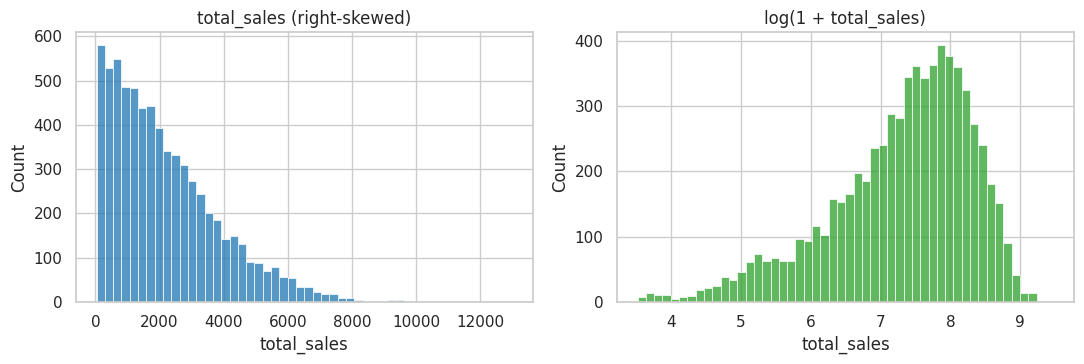

In [6]:
y = train_raw["total_sales"].values
eda = full.iloc[:n_train].copy()
eda["total_sales"] = y

print(eda["total_sales"].describe().round(1))
print("skewness:", round(eda["total_sales"].skew(), 2), "| after log1p:", round(np.log1p(eda["total_sales"]).skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(eda["total_sales"], bins=50, ax=ax[0], color="#1f77b4")
ax[0].set_title("total_sales (right-skewed)")
sns.histplot(np.log1p(eda["total_sales"]), bins=50, ax=ax[1], color="#2ca02c")
ax[1].set_title("log(1 + total_sales)")
savefig("01_target_distribution")

**Finding 1.** Sales are right-skewed: most rows sell little and a few sell a lot. A model that predicts the average would be wrong by about 1,700 on a typical row (the standard deviation), so that is the number to beat.

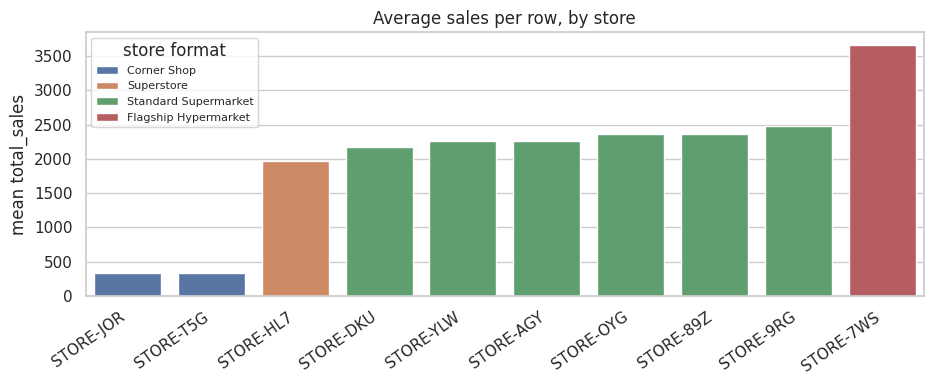

,store_code,store_format,tier,size,age,rows,mean_sales
0,STORE-JOR,Corner Shop,Tier_3,Unknown,34,439,334.0
1,STORE-T5G,Corner Shop,Tier_1,Small,47,427,338.0
2,STORE-HL7,Superstore,Tier_3,Medium,23,742,1972.0
3,STORE-DKU,Standard Supermarket,Tier_2,Unknown,30,736,2177.0
4,STORE-YLW,Standard Supermarket,Tier_1,Small,35,754,2254.0
5,STORE-AGY,Standard Supermarket,Tier_3,Large,45,748,2255.0
6,STORE-OYG,Standard Supermarket,Tier_2,Unknown,25,744,2366.0
7,STORE-89Z,Standard Supermarket,Tier_1,Medium,33,728,2366.0
8,STORE-9RG,Standard Supermarket,Tier_2,Small,28,752,2479.0
9,STORE-7WS,Flagship Hypermarket,Tier_3,Medium,47,748,3660.0


In [7]:
store_info = (eda.groupby("store_code")
                 .agg(store_format=("store_format", "first"),
                      tier=("store_location_tier", "first"),
                      size=("store_size", "first"),
                      age=("store_age_years", "first"),
                      rows=("id", "size"),
                      mean_sales=("total_sales", "mean"))
                 .sort_values("mean_sales").reset_index())

fig, ax = plt.subplots(figsize=(9.5, 4))
sns.barplot(data=store_info, x="store_code", y="mean_sales", hue="store_format", dodge=False, ax=ax)
ax.set_title("Average sales per row, by store")
ax.set_xlabel(""); ax.set_ylabel("mean total_sales")
plt.xticks(rotation=35, ha="right")
ax.legend(title="store format", fontsize=8)
savefig("02_sales_by_store")

store_info.round(0)

**Finding 2.** The store matters a lot. The flagship hypermarket sells about 11 times more per row than a corner shop. Store format explains most of the gap, while location tier and store age show no clear pattern.

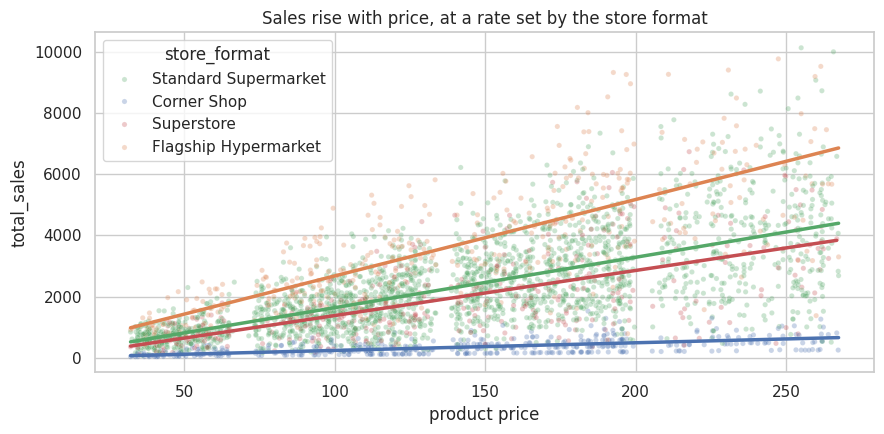

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sample = eda.sample(3500, random_state=1)
palette = dict(zip(sorted(eda["store_format"].unique()), sns.color_palette("deep", 4)))
sns.scatterplot(data=sample, x="price_p", y="total_sales", hue="store_format", palette=palette, alpha=0.3, s=14, ax=ax)
for fmt, grp in eda.groupby("store_format"):
    slope, intercept = np.polyfit(grp["price_p"], grp["total_sales"], 1)
    xs = np.array([grp["price_p"].min(), grp["price_p"].max()])
    ax.plot(xs, slope * xs + intercept, lw=2.5, color=palette[fmt])
ax.set_title("Sales rise with price, at a rate set by the store format")
ax.set_xlabel("product price"); ax.set_ylabel("total_sales")
savefig("03_price_vs_sales")

**Finding 3 (the key one).** Sales grow almost in a straight line with price, and the slope depends on the store. This suggests sales ≈ price × (units sold), where the number of units sold depends on the store. Let us test that by dividing sales by price.

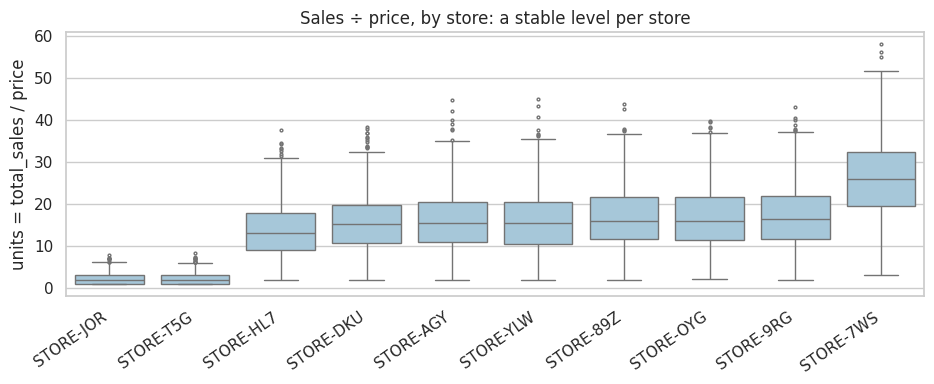

            mean  std  noise_%
store_code                    
STORE-JOR    2.4  1.4     58.0
STORE-T5G    2.5  1.4     56.0
STORE-HL7   13.9  6.6     47.0
STORE-DKU   15.7  6.9     44.0
STORE-AGY   15.9  7.3     46.0
STORE-YLW   16.1  7.3     45.0
STORE-OYG   16.7  7.2     43.0
STORE-89Z   16.8  7.1     42.0
STORE-9RG   17.1  7.3     43.0
STORE-7WS   26.4  9.2     35.0


In [9]:
eda["units"] = eda["total_sales"] / eda["price_p"]          # rough 'units sold'
order = eda.groupby("store_code")["units"].median().sort_values().index

fig, ax = plt.subplots(figsize=(9.5, 4))
sns.boxplot(data=eda, x="store_code", y="units", order=order, color="#9ecae1", fliersize=2, ax=ax)
ax.set_title("Sales ÷ price, by store: a stable level per store")
ax.set_xlabel(""); ax.set_ylabel("units = total_sales / price")
plt.xticks(rotation=35, ha="right")
savefig("04_units_by_store")

units_table = eda.groupby("store_code")["units"].agg(["mean", "std"]).round(1)
units_table["noise_%"] = (units_table["std"] / units_table["mean"] * 100).round(0)
print(units_table.sort_values("mean"))

**Finding 4.** Once we divide by price, each store has its own steady level (about 2.4 for the corner shops up to about 26 for the flagship). Around that level there is a lot of noise (roughly 35% to 60% of the mean). That noise is what limits any model, and we will see it again in the final error.

Now we check whether anything else moves the units sold. We measure each row relative to its store's average, so store differences are removed.

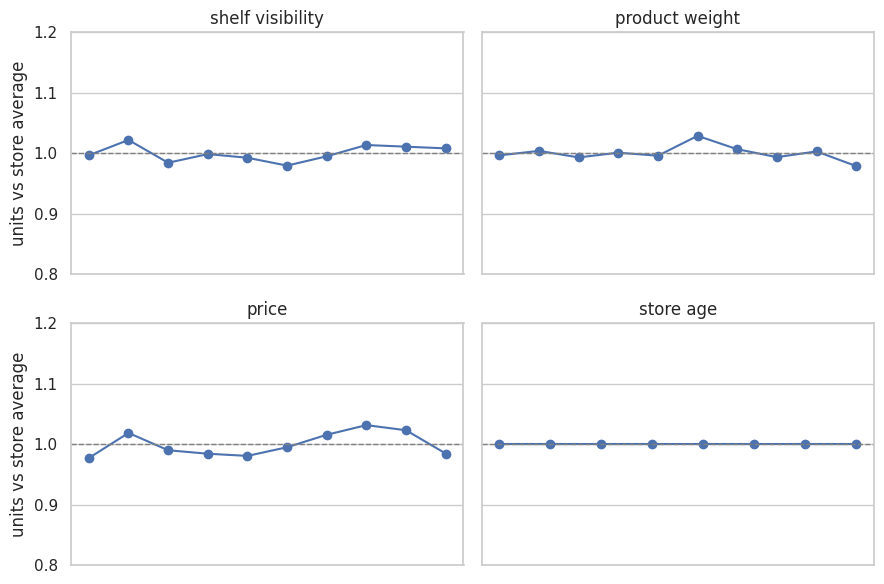

fat content: {'Low Fat': 0.997, 'Regular': 1.006}


In [10]:
eda["rel"] = eda["units"] / eda.groupby("store_code")["units"].transform("mean")   # 1.0 = normal for that store

def binned_mean(ax, series, title, bins=10):
    b = pd.qcut(series, bins, duplicates="drop")
    m = eda.groupby(b, observed=True)["rel"].mean()
    ax.plot(range(len(m)), m.values, marker="o")
    ax.axhline(1, color="grey", ls="--", lw=1)
    ax.set_ylim(0.8, 1.2); ax.set_title(title); ax.set_xticks([])

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharey=True)
ax = axes.ravel()
binned_mean(ax[0], eda["vis_p"], "shelf visibility")
binned_mean(ax[1], eda["weight_p"], "product weight")
binned_mean(ax[2], eda["price_p"], "price")
binned_mean(ax[3], eda["store_age_years"], "store age")
for a in (ax[0], ax[2]):
    a.set_ylabel("units vs store average")
savefig("05_factors_that_do_not_matter")

print("fat content:", eda.groupby("fat_content")["rel"].mean().round(3).to_dict())

**Finding 5.** Shelf visibility, weight, price level, store age and fat content have almost no effect on how many units sell once the store is known. The lines are flat.

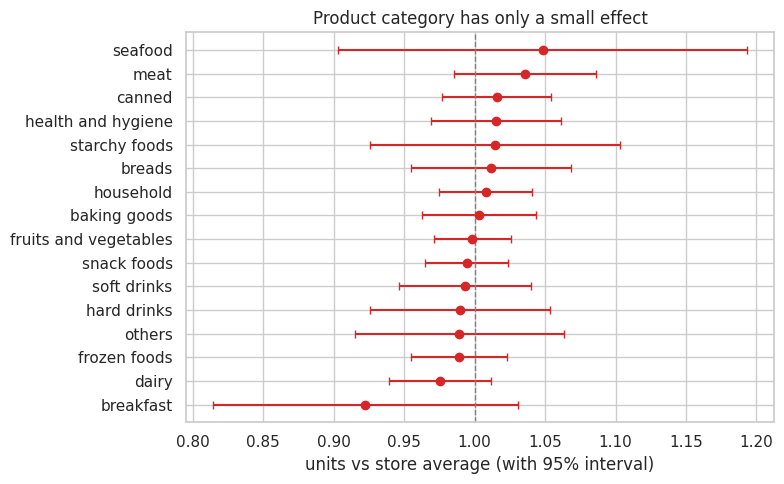

In [11]:
cat = (eda.groupby("product_category")["rel"]
          .agg(["mean", "sem", "count"]).sort_values("mean").reset_index())
cat["ci"] = 1.96 * cat["sem"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(cat["mean"], range(len(cat)), xerr=cat["ci"], fmt="o", color="#d62728", capsize=3)
ax.axvline(1, color="grey", ls="--", lw=1)
ax.set_yticks(range(len(cat))); ax.set_yticklabels(cat["product_category"])
ax.set_xlabel("units vs store average (with 95% interval)")
ax.set_title("Product category has only a small effect")
savefig("06_category_effect")

**Finding 6.** Most categories sit close to 1.0 and their intervals overlap it. Breakfast and dairy look a little lower, and seafood and meat a little higher, but the differences are small compared with the noise.

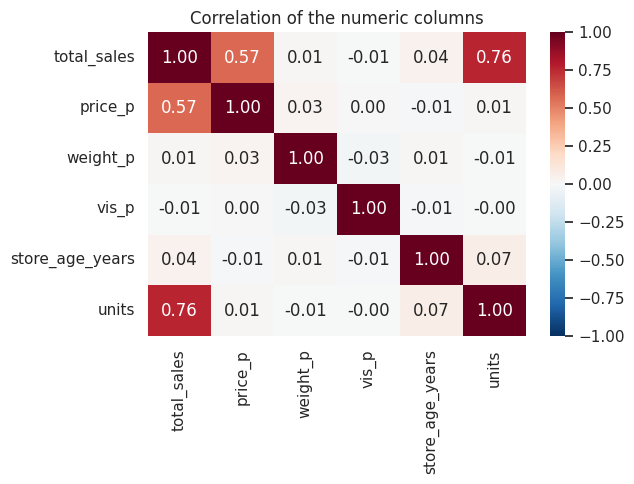

In [12]:
num_cols = ["total_sales", "price_p", "weight_p", "vis_p", "store_age_years", "units"]
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(eda[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation of the numeric columns")
savefig("07_correlation")

In [13]:
# How much of the variation does each idea explain? (descriptive, on the training data)
S = pd.get_dummies(eda["store_code"], dtype=float)

def r2(X, fit_intercept=True):
    m = LinearRegression(fit_intercept=fit_intercept).fit(X, y)
    return m.score(X, y)

r2_table = pd.Series({
    "price only": r2(eda[["price_p"]]),
    "store only": r2(S),
    "price + store (added together)": r2(pd.concat([eda[["price_p"]], S], axis=1)),
    "price x store (sales = price * store rate)": r2(S.mul(eda["price_p"], axis=0), fit_intercept=False),
}).round(3).to_frame("R2")
r2_table

,R2
price only,0.325
store only,0.241
price + store (added together),0.561
price x store (sales = price * store rate),0.604


**Finding 7.** Price alone and store alone each explain only part of the variation. Combining them as a **product** (price × store rate) explains about 60% of it, better than adding them. This confirms the multiplicative structure. The remaining ~40% is noise that none of the other columns explain.

## 4. Feature engineering

From the EDA I built three groups of features. All of them come from the feature columns only.

1. **Denoised product values.** `price_p`, `weight_p`, `vis_p`: one clean value per product instead of a slightly different noisy value on each row.
2. **Relative features.** `price_to_cat` (price versus the category average), `price_per_kg`, and `vis_to_store` (visibility versus the store average).
3. **One-hot encoding** of the store and the other categorical columns.

Then one change to the **target**: instead of predicting `total_sales` directly, the model predicts **units = total_sales / price**, and the prediction is multiplied back by the price. That builds the finding "sales = price × units" into the model, so it does not have to rediscover it from 6,800 noisy rows.

In [14]:
full["price_to_cat"] = full["price_p"] / full.groupby("product_category")["price_p"].transform("mean")
full["price_per_kg"] = full["price_p"] / full["weight_p"]
full["vis_to_store"] = full["vis_p"] / full.groupby("store_code")["vis_p"].transform("mean")

num_features = ["price_p", "weight_p", "vis_p", "price_to_cat", "price_per_kg", "vis_to_store", "store_age_years"]
cat_features = ["store_code", "fat_content", "product_category", "store_size", "store_location_tier", "store_format"]

X_all = pd.concat([full[num_features], pd.get_dummies(full[cat_features], dtype=float)], axis=1)
X_eng = X_all.iloc[:n_train].reset_index(drop=True)          # engineered features, train
X_eng_test = X_all.iloc[n_train:].reset_index(drop=True)     # engineered features, test
store_cols = [c for c in X_eng.columns if c.startswith("store_code_")]

# Baseline features: what you would have after simple cleaning only (raw price, no engineering)
base_cats = ["fat_content", "product_category", "store_size", "store_location_tier", "store_format"]
X_base_all = pd.concat([full[["weight_p", "vis_p", "product_price", "store_age_years"]],
                        pd.get_dummies(full[base_cats], dtype=float)], axis=1)
X_base = X_base_all.iloc[:n_train].reset_index(drop=True)

print("engineered features:", X_eng.shape[1], "| baseline features:", X_base.shape[1])

engineered features: 46 | baseline features: 33


## 5. Build and evaluate models

**How models are compared.** 5-fold cross-validation on the training data with RMSE, the same metric the leaderboard uses. Every model sees the same folds. Cross-validation is more reliable than one train/test split because each row is used for testing exactly once.

Two experiments:
- **A. Baseline features**, predicting `total_sales` directly.
- **B. Engineered features**, predicting `units` and multiplying back by price.

In [15]:
class UnitsRegressor(BaseEstimator, RegressorMixin):
    # Learn units = sales / price with any model, then predict units * price.
    def __init__(self, base=None, price_col="price_p", price_as_feature=True):
        self.base = base
        self.price_col = price_col
        self.price_as_feature = price_as_feature
    def _features(self, X):
        return X if self.price_as_feature else X.drop(columns=self.price_col)
    def fit(self, X, y):
        self.model_ = clone(self.base).fit(self._features(X), y / X[self.price_col].values)
        return self
    def predict(self, X):
        return self.model_.predict(self._features(X)) * X[self.price_col].values

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

def evaluate(experiment, name, model, X):
    oof = np.zeros(n_train)
    fold_scores = []
    for tr_idx, va_idx in kf.split(X):
        m = clone(model).fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = m.predict(X.iloc[va_idx])
        fold_scores.append(rmse(y[va_idx], oof[va_idx]))
    results.append({"experiment": experiment, "model": name,
                    "cv_rmse": rmse(y, oof), "fold_sd": float(np.std(fold_scores))})
    print(f"{experiment:22s} {name:22s} RMSE {rmse(y, oof):8.1f}  (fold sd {np.std(fold_scores):.1f})")
    return oof

def model_zoo():
    zoo = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=10),
        "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=10, max_features=0.5, n_jobs=-1, random_state=SEED),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=SEED),
    }
    if lgb is not None:
        zoo["LightGBM"] = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=8, min_child_samples=40,
                                            subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=5,
                                            random_state=SEED, verbose=-1)
    if xgb is not None:
        zoo["XGBoost"] = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=3, min_child_weight=20,
                                          subsample=0.8, colsample_bytree=0.8, reg_lambda=5, random_state=SEED)
    if CatBoostRegressor is not None:
        zoo["CatBoost"] = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=4, l2_leaf_reg=5,
                                            random_seed=SEED, verbose=0)
    return zoo

# Reference: always predict the training average
oof_mean = np.zeros(n_train)
for tr_idx, va_idx in kf.split(X_base):
    oof_mean[va_idx] = y[tr_idx].mean()
results.append({"experiment": "Reference", "model": "Predict the average",
                "cv_rmse": rmse(y, oof_mean), "fold_sd": np.nan})
print(f"Reference: predicting the average gives RMSE {rmse(y, oof_mean):.1f}")

Reference: predicting the average gives RMSE 1697.9


### Experiment A: baseline features, predicting sales directly

In [16]:
oof_A = {}
for name, model in model_zoo().items():
    oof_A[name] = evaluate("A. baseline features", name, model, X_base)

A. baseline features   Linear Regression      RMSE   1130.5  (fold sd 23.8)
A. baseline features   Ridge                  RMSE   1130.5  (fold sd 23.9)


A. baseline features   Random Forest          RMSE   1087.9  (fold sd 20.9)


A. baseline features   Gradient Boosting      RMSE   1086.2  (fold sd 21.6)


A. baseline features   LightGBM               RMSE   1083.0  (fold sd 21.7)


A. baseline features   XGBoost                RMSE   1081.9  (fold sd 21.7)


A. baseline features   CatBoost               RMSE   1083.3  (fold sd 22.6)


### Experiment B: engineered features, predicting units
The **Structural** model is the simplest version of the idea: predict `price × the store's average units`. It uses only two ingredients (price and store) and no machine learning algorithm beyond averages.

In [17]:
oof_B = {}

# Structural model: price x the store's average units
structural = UnitsRegressor(LinearRegression(), price_as_feature=False)
oof_B["Structural (price x store)"] = evaluate("B. engineered + units", "Structural (price x store)",
                                                structural, X_eng[["price_p"] + store_cols])

for name, model in model_zoo().items():
    if name == "Linear Regression":
        continue                      # same idea as Ridge here
    oof_B[name] = evaluate("B. engineered + units", name, UnitsRegressor(model), X_eng)

B. engineered + units  Structural (price x store) RMSE   1071.1  (fold sd 20.8)
B. engineered + units  Ridge                  RMSE   1073.4  (fold sd 21.3)


B. engineered + units  Random Forest          RMSE   1086.2  (fold sd 23.2)


B. engineered + units  Gradient Boosting      RMSE   1077.9  (fold sd 23.3)


B. engineered + units  LightGBM               RMSE   1078.2  (fold sd 24.0)


B. engineered + units  XGBoost                RMSE   1075.4  (fold sd 22.8)


B. engineered + units  CatBoost               RMSE   1077.8  (fold sd 23.6)


In [18]:
res = pd.DataFrame(results).sort_values("cv_rmse").reset_index(drop=True)
res["cv_rmse"] = res["cv_rmse"].round(1)
res["fold_sd"] = res["fold_sd"].round(1)
res

,experiment,model,cv_rmse,fold_sd
0,B. engineered + units,Structural (price x store),1071.1,20.8
1,B. engineered + units,Ridge,1073.4,21.3
2,B. engineered + units,XGBoost,1075.4,22.8
3,B. engineered + units,CatBoost,1077.8,23.6
4,B. engineered + units,Gradient Boosting,1077.9,23.3
5,B. engineered + units,LightGBM,1078.2,24.0
6,A. baseline features,XGBoost,1081.9,21.7
7,A. baseline features,LightGBM,1083.0,21.7
8,A. baseline features,CatBoost,1083.3,22.6
9,B. engineered + units,Random Forest,1086.2,23.2


### Reading the results
- Feature engineering helps the plain linear model the most: it improves a lot once it can see the price × store structure.
- Every good model lands close to the same score. The models are not the limit, the noise in the data is.
- Differences of a few RMSE points are smaller than the fold-to-fold variation (the `fold_sd` column), so they should not be over-read.

### Tuning
I tune XGBoost with a random search over its main settings. The tuned score is slightly optimistic because the same folds choose the settings and report the score, so I treat it as a small improvement at best.

In [19]:
if xgb is not None:
    search = RandomizedSearchCV(
        UnitsRegressor(xgb.XGBRegressor(random_state=SEED)),
        param_distributions={
            "base__max_depth": [2, 3, 4],
            "base__learning_rate": [0.02, 0.03, 0.05, 0.08],
            "base__n_estimators": [100, 200, 300, 500],
            "base__min_child_weight": [10, 20, 50, 100],
            "base__subsample": [0.6, 0.8, 1.0],
            "base__colsample_bytree": [0.5, 0.8, 1.0],
            "base__reg_lambda": [1, 5, 10, 30],
        },
        n_iter=25, scoring="neg_root_mean_squared_error", cv=kf, random_state=SEED, n_jobs=1)
    search.fit(X_eng, y)
    print("best settings:", {k.replace("base__", ""): v for k, v in search.best_params_.items()})
    print("best CV RMSE :", round(-search.best_score_, 1))
    tuned_xgb = clone(search.best_estimator_)
    oof_B["XGBoost (tuned)"] = evaluate("B. engineered + units", "XGBoost (tuned)", tuned_xgb, X_eng)

best settings: {'subsample': 0.8, 'reg_lambda': 30, 'n_estimators': 300, 'min_child_weight': 50, 'max_depth': 2, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
best CV RMSE : 1071.7


B. engineered + units  XGBoost (tuned)        RMSE   1071.9  (fold sd 20.8)


### Ensemble
Averaging models that make different kinds of mistakes can make predictions more stable. I average four members: the structural model, Ridge, tuned XGBoost and CatBoost (when available), all on the units target.

In [20]:
members = {
    "Structural (price x store)": (UnitsRegressor(LinearRegression(), price_as_feature=False), ["price_p"] + store_cols),
    "Ridge": (UnitsRegressor(Ridge(alpha=10)), list(X_eng.columns)),
}
if xgb is not None:
    members["XGBoost (tuned)"] = (tuned_xgb, list(X_eng.columns))
if CatBoostRegressor is not None:
    members["CatBoost"] = (UnitsRegressor(model_zoo()["CatBoost"]), list(X_eng.columns))

blend_oof = np.mean([oof_B[name] for name in members], axis=0)
blend_rmse = rmse(y, blend_oof)
blend_folds = [rmse(y[va], blend_oof[va]) for _, va in kf.split(X_eng)]
results.append({"experiment": "B. engineered + units", "model": "Ensemble (average)",
                "cv_rmse": blend_rmse, "fold_sd": float(np.std(blend_folds))})
print("members:", list(members))
print(f"Ensemble CV RMSE: {blend_rmse:.1f}  (fold sd {np.std(blend_folds):.1f})")
print(f"Improvement over predicting the average: {(1 - blend_rmse / rmse(y, oof_mean)) * 100:.0f}%")
print(f"R2 of the ensemble (out-of-fold): {1 - np.sum((y - blend_oof)**2) / np.sum((y - y.mean())**2):.3f}")

members: ['Structural (price x store)', 'Ridge', 'XGBoost (tuned)', 'CatBoost']
Ensemble CV RMSE: 1071.5  (fold sd 21.6)
Improvement over predicting the average: 37%
R2 of the ensemble (out-of-fold): 0.602


In [21]:
res_all = pd.DataFrame(results).sort_values("cv_rmse").reset_index(drop=True)
res_all["cv_rmse"] = res_all["cv_rmse"].round(1)
res_all["fold_sd"] = res_all["fold_sd"].round(1)
res_all

,experiment,model,cv_rmse,fold_sd
0,B. engineered + units,Structural (price x store),1071.1,20.8
1,B. engineered + units,Ensemble (average),1071.5,21.6
2,B. engineered + units,XGBoost (tuned),1071.9,20.8
3,B. engineered + units,Ridge,1073.4,21.3
4,B. engineered + units,XGBoost,1075.4,22.8
5,B. engineered + units,CatBoost,1077.8,23.6
6,B. engineered + units,Gradient Boosting,1077.9,23.3
7,B. engineered + units,LightGBM,1078.2,24.0
8,A. baseline features,XGBoost,1081.9,21.7
9,A. baseline features,LightGBM,1083.0,21.7


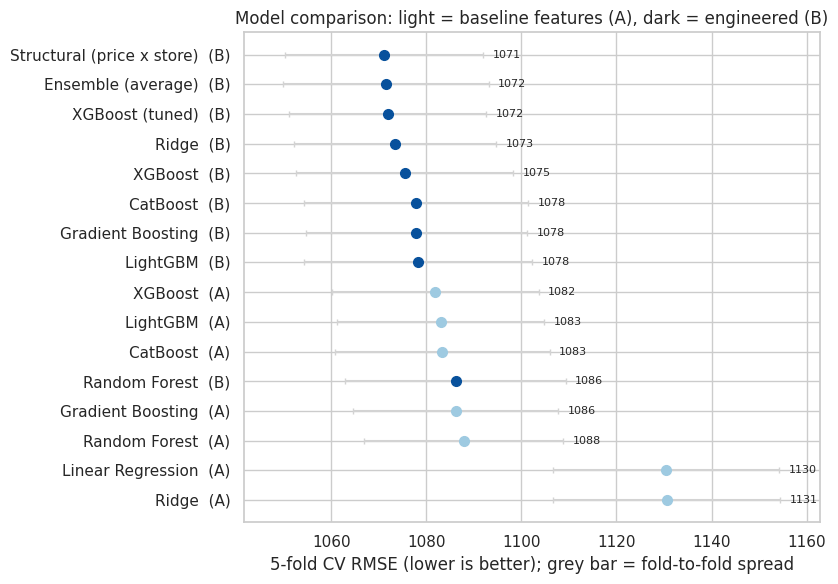

In [22]:
res_all = pd.DataFrame(results).sort_values("cv_rmse").reset_index(drop=True)
plot_df = res_all[res_all["experiment"] != "Reference"].copy()
plot_df["label"] = plot_df["model"] + "  (" + plot_df["experiment"].str[0] + ")"
plot_df = plot_df.sort_values("cv_rmse", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 6))
for i, row in plot_df.iterrows():
    color = "#9ecae1" if row["experiment"].startswith("A") else "#08519c"
    ax.errorbar(row["cv_rmse"], i, xerr=row["fold_sd"], fmt="o", color=color, ecolor="lightgrey", capsize=2, ms=7)
    ax.text(row["cv_rmse"] + row["fold_sd"] + 2, i, f'{row["cv_rmse"]:.0f}', va="center", fontsize=8)
ax.set_yticks(range(len(plot_df))); ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("5-fold CV RMSE (lower is better); grey bar = fold-to-fold spread")
ax.set_title("Model comparison: light = baseline features (A), dark = engineered (B)")
ax.margins(x=0.08)
savefig("08_model_comparison")

**Result.** The ensemble scores the same as the best single model, within the fold-to-fold noise. I still use it as the final model because averaging protects against one model's quirks on unseen data. The simple structural model is an equally valid choice and is the easiest to explain.

### Where does the remaining error come from?

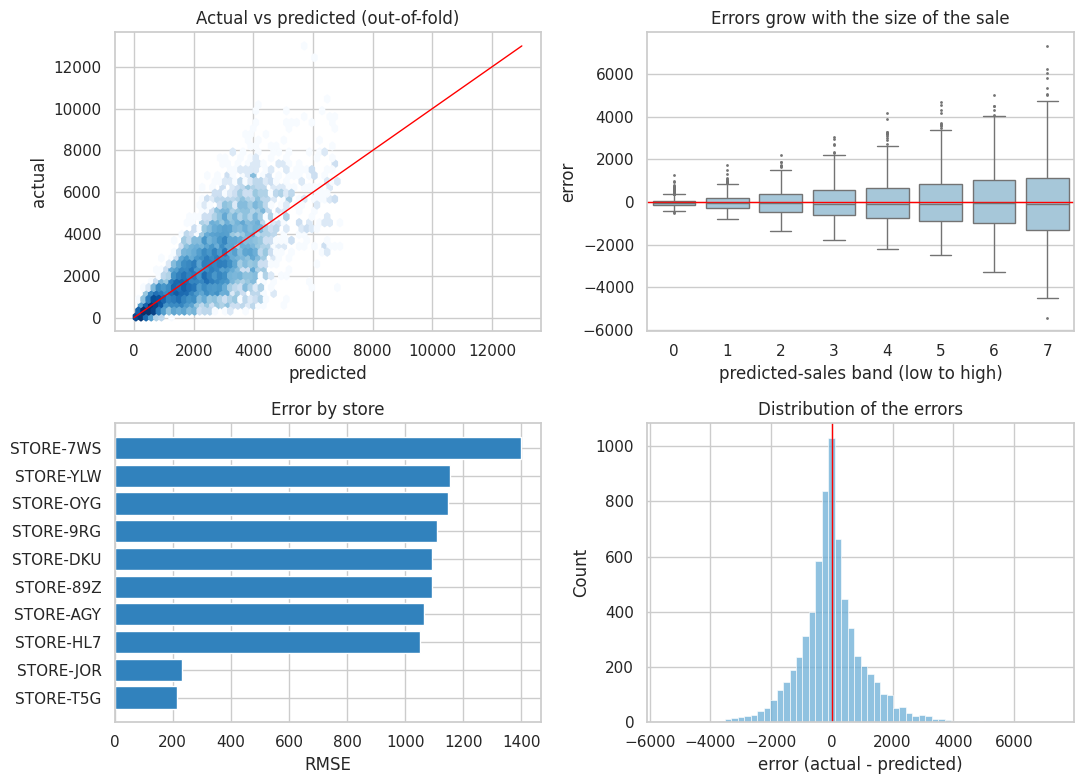

In [23]:
resid = y - blend_oof
diag = pd.DataFrame({"actual": y, "pred": blend_oof, "resid": resid,
                     "store_code": train_raw["store_code"], "price": X_eng["price_p"]})

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes.ravel()

ax[0].hexbin(diag["pred"], diag["actual"], gridsize=40, cmap="Blues", mincnt=1, bins="log")
lim = [0, diag[["pred", "actual"]].values.max()]
ax[0].plot(lim, lim, color="red", lw=1)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual"); ax[0].set_title("Actual vs predicted (out-of-fold)")

diag["pred_band"] = pd.qcut(diag["pred"], 8, labels=False)
sns.boxplot(data=diag, x="pred_band", y="resid", color="#9ecae1", fliersize=1, ax=ax[1])
ax[1].axhline(0, color="red", lw=1)
ax[1].set_xlabel("predicted-sales band (low to high)"); ax[1].set_ylabel("error"); ax[1].set_title("Errors grow with the size of the sale")

store_rmse = diag.groupby("store_code").apply(lambda g: rmse(g["actual"], g["pred"])).sort_values()
ax[2].barh(store_rmse.index, store_rmse.values, color="#3182bd")
ax[2].set_xlabel("RMSE"); ax[2].set_title("Error by store")

sns.histplot(diag["resid"], bins=60, color="#6baed6", ax=ax[3])
ax[3].axvline(0, color="red", lw=1)
ax[3].set_xlabel("error (actual - predicted)"); ax[3].set_title("Distribution of the errors")
savefig("09_diagnostics")

The predictions follow the actual values without bias, but the spread of the errors grows with the size of the sale. That is what multiplicative noise looks like: a product that sells 30% more or fewer units than usual moves the total by 30% of a bigger number. The stores with the largest sales therefore carry most of the RMSE. This is the reason no model can drive the error much lower than about 1,070 here.

## 6. Generate predictions for the test data
The final models are refit on **all** the training rows and their predictions are averaged.

In [24]:
test_preds = []
for name, (model, cols) in members.items():
    fitted = clone(model).fit(X_eng[cols], y)
    test_preds.append(fitted.predict(X_eng_test[cols]))

final_pred = np.clip(np.mean(test_preds, axis=0), 0, None)     # sales cannot be negative

submission = pd.DataFrame({"id": test_raw["id"], "total_sales": final_pred})
submission.to_csv("submission.csv", index=False)

# Sanity checks
assert len(submission) == len(test_raw)
assert submission["id"].tolist() == test_raw["id"].tolist()
assert submission["total_sales"].notna().all()
print("saved submission.csv:", submission.shape)

compare = pd.DataFrame({"train actual": pd.Series(y).describe(),
                        "test predicted": submission["total_sales"].describe()}).round(1)
compare

saved submission.csv: (1705, 2)


,train actual,test predicted
count,6818.0,1705.0
mean,2174.8,2195.0
std,1697.9,1321.6
min,32.7,76.0
25%,834.8,1173.6
50%,1790.9,2057.6
75%,3092.6,3058.9
max,12996.8,6849.9


In [25]:
submission.head()

,id,total_sales
0,row_00009,2795.379060
1,row_00015,4536.825320
2,row_00019,2965.850753
3,row_00020,3112.497160
4,row_00023,2511.187317


The predicted test sales have a similar centre to the actual training sales but a narrower spread. That is expected: a model predicts the typical (expected) value for each row and cannot reproduce the random noise, so its predictions are always less spread out than real outcomes.

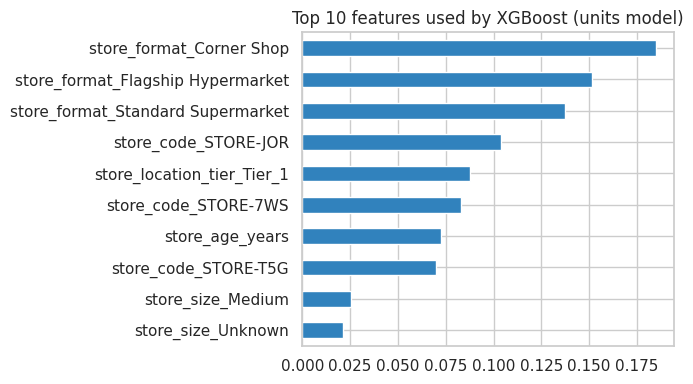

In [26]:
# Which inputs does the tuned XGBoost (units) model use most?
if xgb is not None:
    fitted_xgb = clone(tuned_xgb).fit(X_eng, y)
    imp = pd.Series(fitted_xgb.model_.feature_importances_, index=X_eng.columns).sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(7, 4))
    imp.iloc[::-1].plot.barh(color="#3182bd", ax=ax)
    ax.set_title("Top 10 features used by XGBoost (units model)")
    savefig("10_feature_importance")

All ten of the most-used features describe the store. That matches the EDA: the store sets the level of units sold, and the other columns add very little on top of it.

In [27]:
# Save the numbers used in the written report
res_final = pd.DataFrame(results).sort_values("cv_rmse").reset_index(drop=True)
store_summary = store_info.merge(units_table.reset_index()[["store_code", "mean", "noise_%"]].rename(
    columns={"mean": "units_mean", "noise_%": "units_noise_pct"}), on="store_code")
store_summary["rmse"] = store_summary["store_code"].map(store_rmse)

summary = {
    "n_train": int(n_train), "n_test": int(len(test_raw)),
    "categories_before": int(train_raw["product_category"].nunique()),
    "categories_after": int(full["product_category"].nunique()),
    "mean_baseline_rmse": rmse(y, oof_mean),
    "ensemble_rmse": blend_rmse,
    "ensemble_fold_sd": float(np.std(blend_folds)),
    "ensemble_r2": float(1 - np.sum((y - blend_oof) ** 2) / np.sum((y - y.mean()) ** 2)),
    "members": list(members),
    "r2_table": r2_table["R2"].to_dict(),
}
res_final.to_csv("results_table.csv", index=False)
store_summary.to_csv("store_summary.csv", index=False)
json.dump(summary, open("summary.json", "w"), indent=2)
print(json.dumps(summary, indent=2))

{
  "n_train": 6818,
  "n_test": 1705,
  "categories_before": 48,
  "categories_after": 16,
  "mean_baseline_rmse": 1697.920068482205,
  "ensemble_rmse": 1071.5310646295843,
  "ensemble_fold_sd": 21.602407098603663,
  "ensemble_r2": 0.6016621282620909,
  "members": [
    "Structural (price x store)",
    "Ridge",
    "XGBoost (tuned)",
    "CatBoost"
  ],
  "r2_table": {
    "price only": 0.325,
    "store only": 0.241,
    "price + store (added together)": 0.561,
    "price x store (sales = price * store rate)": 0.604
  }
}


## 7. Communicate: findings and recommendations

### What drives sales
1. **The store is the biggest driver.** The flagship hypermarket sells about 11 times more per row than a corner shop. Store format matters much more than location tier or store age.
2. **Price scales sales.** Within a store, sales grow in proportion to price. A useful way to think about it is sales ≈ price × units sold, with a steady level of units per store.
3. **Almost nothing else matters.** Shelf visibility, product weight, fat content and store age show no clear effect. Product category has a small effect at most.

### How good is the model
- Predicting the average gives an RMSE of about 1,700. The final ensemble reaches about **1,070**, explaining roughly 60% of the variation.
- Many different models reach nearly the same score, and their gaps are smaller than the fold-to-fold variation. The remaining error is mostly random variation in units sold, not a modelling weakness.

### Recommendations for DSN Mart
- **Stock and pricing plans** should start from the store format and the product price: expected sales are close to price × the store's typical units.
- **Investment decisions:** the format gap is large. Moving a location up a format tier is worth far more than adjusting shelf space or product mix at the margin.
- **Shelf space:** the data does not show that more visibility raises units sold once the store is known. Test this with a controlled experiment before changing layouts.

### Limitations and next steps
- The data is a snapshot, with no dates, so trends and seasonality cannot be studied.
- Only ten stores exist, so conclusions about "location tier" and "size" rest on very few stores.
- If competition rules allow, extra data (promotions, stock-outs, local income) is the most likely way to explain the remaining noise.
- Product-level effects (some products being more popular than others) were checked and are weak, with roughly 5 rows per product.